# Práctica 2: Clustering de Semillas
## Aprendizaje No Supervisado

En esta práctica se aplican técnicas de agrupamiento (clustering) sobre un conjunto de datos que describe distintas características físicas de semillas. El objetivo es comprobar si existen agrupaciones naturales en los datos y evaluar qué técnicas de clustering se ajustan mejor.

Se compararán tres técnicas principales:
- **K-Means**
- **Clustering Jerárquico (Hierarchical Clustering)**
- **DBSCAN**

Para la visualización de los resultados se utilizará una reducción de dimensionalidad mediante PCA a 2 dimensiones. También se analizará la correspondencia entre los clusters generados y las clases originales de semillas.

**Autores:** Raúl Armas Seriñá, Jordan-Ikukele Bomolo Mia  
**Grupo o NIA:** ?

Importamos las librerías necesarias antes de comenzar

In [25]:
# Librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

**Carga del DataSet**

Procedemos a cargar el dataset y prepararlo para el análisis

In [26]:
# Cargar los datos
df = pd.read_csv("semillas.csv")

# Mostrar las primeras filas y la info general
display(df.head())
df.info()

,area,perimetro,compacidad,longitud,anchura,asimetria,surco,clase
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area        210 non-null    float64
 1   perimetro   210 non-null    float64
 2   compacidad  210 non-null    float64
 3   longitud    210 non-null    float64
 4   anchura     210 non-null    float64
 5   asimetria   210 non-null    float64
 6   surco       210 non-null    float64
 7   clase       210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.2 KB


Ahora podemos separar los atributos (X) y las clases (Y). El clustering es no supervisado, por lo que no se va a usar una columna "y" para entrenar (solo para comparar resultados).

In [27]:
X = df.drop("clase", axis=1)
y = df["clase"]

### **Comparativa y Visualización de los Scalers con PCA**

Preparamos los 3 scalers que vamos a probar. PCA necesita que los datos esten escalados, ya que los atributos tienen magnitudes distintas. Sabemos que:

    •	MinMaxScaler: pone cada atributo entre 0 y 1.
	•	StandardScaler: centra la media en 0 y la desv. típica en 1.
	•	RobustScaler: usa la mediana y el IQR → más robusto a outliers.

In [28]:
# Preparar scalers y nombres
scalers = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler()
}

Escalaremos los datos con cada uno de los scalers, los reduciremos a 2 dimensiones con PCA para poder hacer gráficas y mostraremos cada caso en un gráfico 2d.

Ahora vamos a crear una figura con 3 subgráficos en línea (uno para cada escalado). Así, podremos comparar de forma visual los resultados del PCA en cada escalado. (Los gráficos están vacíos, aún no dibujamos nada en ellos)

NOTA: PCA (Análisis de Componentes Principales) es una técnica de reducción de dimensionalidad

Text(0.5, 0.98, 'Comparación visual de escalados con PCA (sin usar la clase)')

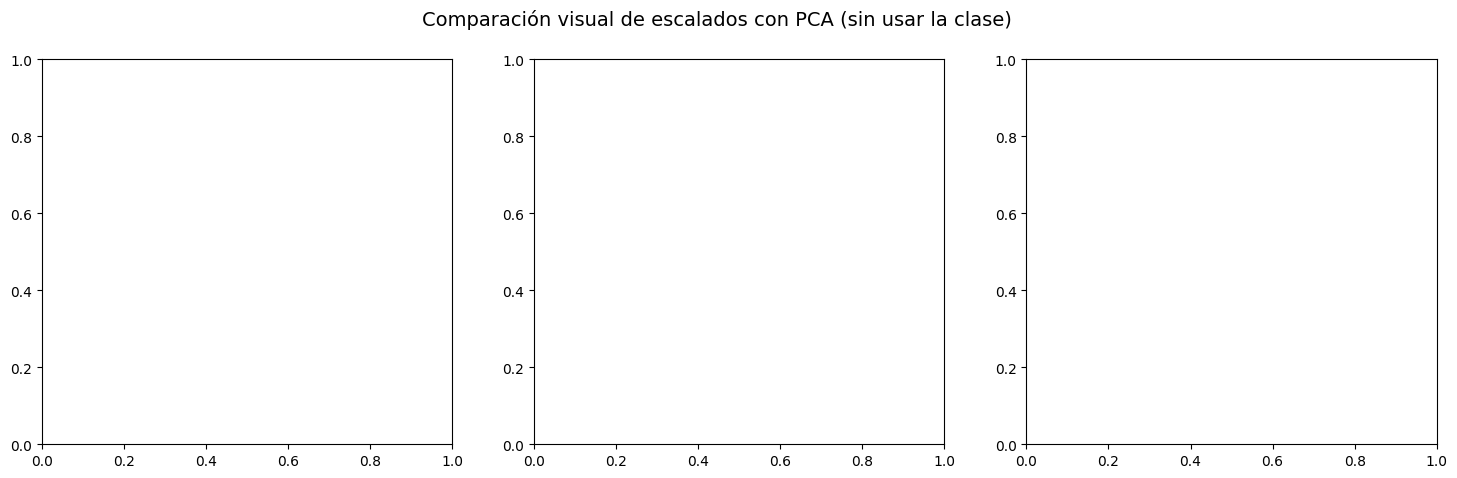

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # fig tiene todos los gráficos y axes es la lista de subgráficos
fig.suptitle("Comparación visual de escalados con PCA (sin usar la clase)", fontsize=14)

### Iterar por cada scaler

Recorremos cada scaler. En cada iteración:
1. Aplicamos el escalado a los datos originales (`X`).
2. Aplicamos PCA a los datos escalados, reduciendo de muchas dimensiones a solo 2.
3. Mostramos los datos proyectados con `scatter`.

NOTA: Nos daba un error raro si separabamos el codigo en partes, así que hemos vuelto a poner el codigo completo aquí

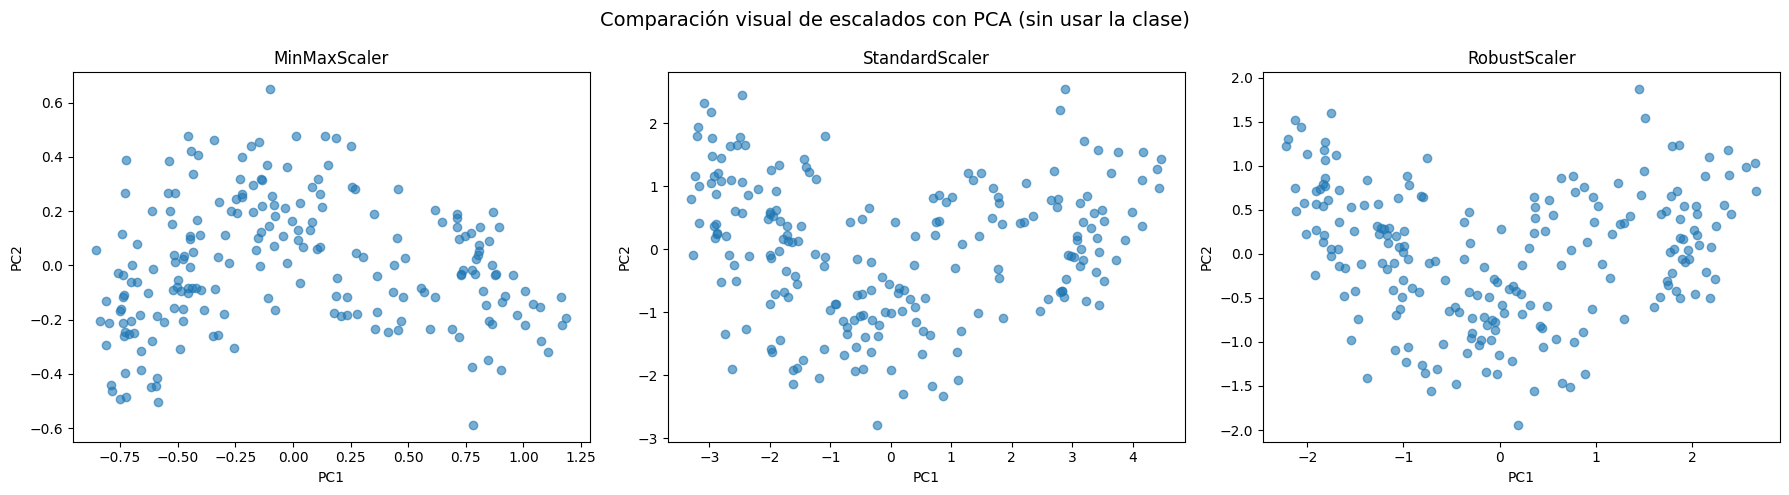

In [30]:

scalers = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler()
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Comparación visual de escalados con PCA (sin usar la clase)", fontsize=14)


for ax, (nombre, scaler) in zip(axes, scalers.items()):
    # Escalamos los datos
    """Transformamos los datos `X` con el scaler actual. 
     El resultado es una nueva versión de los datos en la que todos los
     atributos tienen una escala similar (según el tipo de scaler)."""
    X_scaled = scaler.fit_transform(X)
    
    # Aplicamos PCA con 2 componentes para reducir los datos a 2D y así poder ver el gráfico
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled) # aquí "aprende" de los datos y el transform aplica la transformación
    
    # Dibujamos el gráfico 2D
    ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
    ax.set_title(nombre)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout() # así no solapan
plt.show()

### Análisis visual de los escalados

Los tres gráficos muestran cómo quedan distribuidos los datos tras aplicar PCA a cada tipo de escalado.

- **MinMaxScaler**: los puntos forman una especie de “n”. Este tipo de escalado puede distorsionar un poco la estructura si hay valores extremos (outliers), ya que comprime todos los datos entre 0 y 1.

- **StandardScaler** y **RobustScaler**: ambos muestran una forma más clara de “U” o “V”, con una separación aparente entre grupos. Esto parece indicar que podrían conservar mejor la estructura real de los datos.

En general, **StandardScaler** es una buena opción por defecto, ya que estandariza los datos centrando la media y ajustando la desviación típica.

**PIPELINE**

Ahora vamos a compactar el bloque en una pipeline (asi es reutilizable el código).

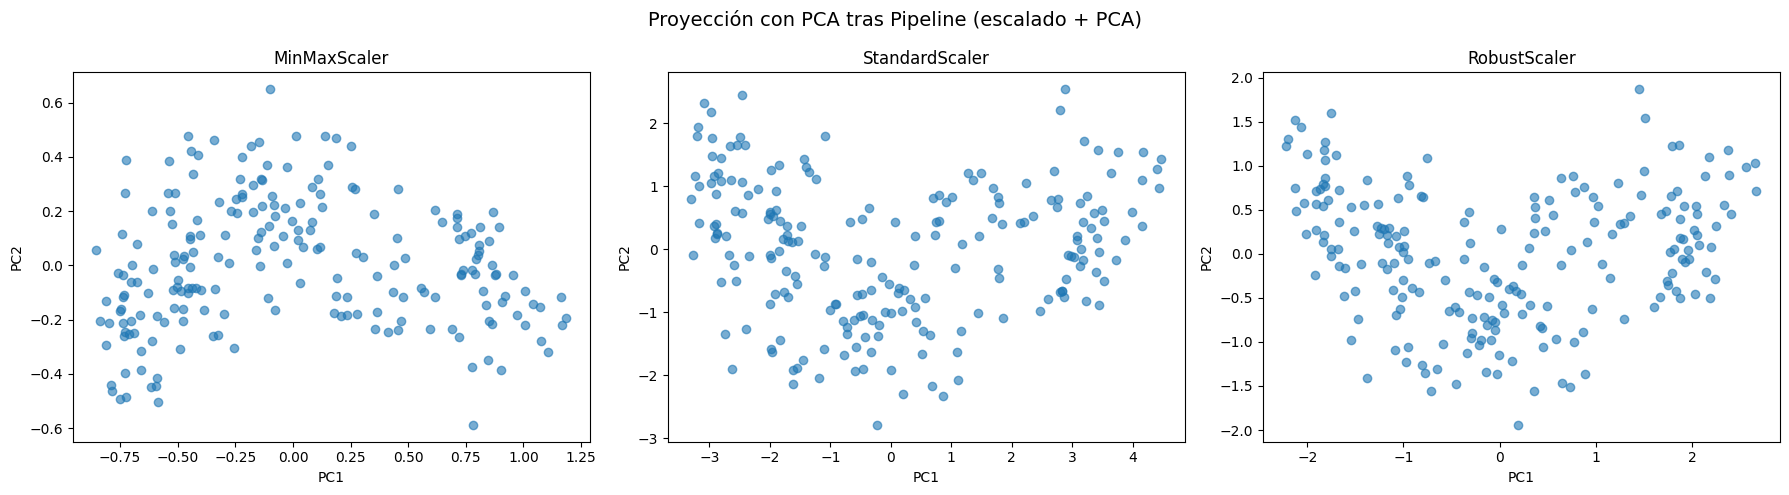

In [31]:

# Definimos los tres pipelines
pipelines = {
    "MinMaxScaler": Pipeline([
        ('scaler', MinMaxScaler()),
        ('pca', PCA(n_components=2))
    ]),
    "StandardScaler": Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=2))
    ]),
    "RobustScaler": Pipeline([
        ('scaler', RobustScaler()),
        ('pca', PCA(n_components=2))
    ])
}

# Creamos los subplots para visualizar
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Proyección con PCA tras Pipeline (escalado + PCA)", fontsize=14)

for ax, (nombre, pipe) in zip(axes, pipelines.items()):
    X_pca = pipe.fit_transform(X)
    ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
    ax.set_title(nombre)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()